# LLM-Assisted Causal Discovery and Inference with DoWhy

This notebook demonstrates a modern causal workflow:

1. Use a local LLM to propose *plausible* causal relationships (a semantic prior)
2. Visualize that proposed DAG
3. Compare with statistical causal discovery (PC algorithm)
4. Estimate a causal effect with DoWhy

We use the **Lalonde** job training dataset.

**Core message:** LLMs can help formulate causal assumptions, but causal validity still requires statistical testing and scientific judgment.


## 2. Imports
We keep imports explicit and minimal.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import networkx as nx

from openai import OpenAI

import dowhy.datasets
from dowhy import CausalModel

# Make sure we can import from src/ when running the notebook from notebooks/
repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.prompts import CAUSAL_DISCOVERY_PROMPT
from src.llm_causal import (
    build_backdoor_dot_graph,
    build_prompt_with_reasons,
    draw_edge_list_dag,
    draw_pc_graph,
    parse_edges_from_llm_output,
    pc_graph_to_edge_lists,
    propose_dag_with_reasons,
    run_pc,
)


## 3. Load Lalonde dataset

Referenz:

- LaLonde, R. J. (1986). Evaluating the econometric evaluations of training programs with experimental data. The American Economic Review, 76(4), 604–620.

The research question is:

> Does participation in a job training program causally increase future income?

In [2]:
df = dowhy.datasets.lalonde_dataset()
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (445, 12)
Columns: ['treat', 'age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75', 're78', 'u74', 'u75']


,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,False,23.0,10.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
1,False,26.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,12383.68,1.0,1.0
2,False,22.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
3,False,18.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,10740.08,1.0,1.0
4,False,45.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,11796.47,1.0,1.0


## 4. Variable overview

## Treatment and Outcome
| Variable | Description |
| :--- | :--- |
| `treat` | **Treatment:** Binary indicator of participation in the job training program (1 = treated, 0 = control). |
| `re78` | **Primary Outcome:** Real earnings in 1978 (post-treatment outcome), used for causal effect estimation. |

## Pre-treatment Covariates 
| Variable | Description |
| :--- | :--- |
| `age` | Age of the individual at baseline. |
| `educ` | Years of formal education. |
| `black` | Indicator variable (1 if individual is Black, 0 otherwise). |
| `hisp` | Indicator variable (1 if individual is Hispanic, 0 otherwise). |
| `married` | Indicator for marital status (1 if married, 0 otherwise). |
| `nodegr` | Indicator for having no high school degree (1 = no degree, 0 = degree). |

## Historical Earnings 
| Variable | Description |
| :--- | :--- |
| `re74` | Real earnings in 1974 (pre-treatment labor market income). |
| `re75` | Real earnings in 1975 (pre-treatment labor market income). |

## Employment Status Indicators
| Variable | Description |
| :--- | :--- |
| `u74` | Unemployment status in 1974 (1 = unemployed, 0 = employed). |
| `u75` | Unemployment status in 1975 (1 = unemployed, 0 = employed). |


## 5. Configure local LLM

This notebook uses the **OpenAI Python SDK** against an **OpenAI-compatible local server**.

Defaults:
- Ollama base URL: `http://localhost:11434/v1`
- Model: `phi4`

To use **LM Studio**, change `BASE_URL` to something like `http://localhost:1234/v1`.

No secrets are required: we set a dummy API key because the OpenAI SDK expects one.


In [3]:
# LOCAL: use ollama 
BASE_URL = 'http://localhost:11434/v1'
MODEL = 'qwen3.5:9b'

client = OpenAI(base_url=BASE_URL, api_key='ollama') # or 'lmstudio' if that is used
BASE_URL, MODEL


## Use of cloud model (e.g. gpt-4o)
# Assumes you exported your API-KEY: 
# export OPENAI_API_KEY='your-actual-key-here'  (Linux / Mac)
# $env:OPENAI_API_KEY="your-actual-key-here"    (Windows Powershell)


#BASE_URL = 'https://api.openai.com/v1'
#MODEL = 'gpt-4o'

# Use your API key (or environment variable)
#client = OpenAI(
#    api_key=os.getenv('OPENAI_API_KEY'),  # or pass directly for testing
#    base_url=BASE_URL,
#)


('http://localhost:11434/v1', 'qwen3.5:9b')

## 6. LLM-assisted causal discovery

The LLM here is a **semantic hypothesis generator**: it can propose confounders and plausible directions.

It does **not** prove causality. We will still compare with statistical discovery and (most importantly) apply scientific judgment.


### Notebook import note

To keep the main notebook readable, we import helper functions from `src/llm_causal/`.
We add the repository root to `sys.path` in the **Imports** cell so these imports work when running from `notebooks/`.


### Extended structured output: edges **with reasons**

To make the LLM output more useful for teaching, we ask for a JSON schema that includes a short justification for each edge.

**Schema (JSON only):**
```json
{
  "edges": [
    {"cause": "educ", "effect": "treat", "reason": "..."},
    {"cause": "treat", "effect": "re78", "reason": "..."}
  ]
}
```

We will still extract a plain edge list `[(cause, effect), ...]` for graph drawing, but we also keep a `(cause, effect) -> reason` mapping for discussion.


In [4]:
# We keep the base prompt in src/prompts.py, and extend it here to request per-edge reasons.
CAUSAL_DISCOVERY_PROMPT_WITH_REASONS = build_prompt_with_reasons(CAUSAL_DISCOVERY_PROMPT)


In [5]:
llm_text, edges, edge_reasons = propose_dag_with_reasons(
    client=client,
    model=MODEL,
    prompt_with_reasons=CAUSAL_DISCOVERY_PROMPT_WITH_REASONS,
)
print(llm_text)

if edge_reasons:
    print('\nEdge reasons (1 sentence each):')
    for (a, b), r in edge_reasons.items():
        print(f"- {a} -> {b}: {r}")


{
  "edges": [
    {
      "cause": "educ",
      "effect": "treat",
      "reason": "Higher education levels influence selection into job training programs."
    },
    {
      "cause": "educ",
      "effect": "re78",
      "reason": "Education is a primary determinant of labor market earnings."
    },
    {
      "cause": "age",
      "effect": "treat",
      "reason": "Age affects eligibility and likelihood of participating in training."
    },
    {
      "cause": "age",
      "effect": "re78",
      "reason": "Earnings typically vary with age due to experience accumulation."
    },
    {
      "cause": "re74",
      "effect": "treat",
      "reason": "Past earnings influence the decision to seek additional training."
    },
    {
      "cause": "re74",
      "effect": "re78",
      "reason": "Historical earnings are strong predictors of future earnings persistence."
    },
    {
      "cause": "u74",
      "effect": "treat",
      "reason": "Unemployment status often drives partic

#### Design note: extended schema vs. a different two-step approach

**Extended JSON schema (used above):** We ask for edges and reasons in one JSON response.
- **Pros:** reasons stay aligned with edges; easy to display a per-edge explanation in the notebook.
- **Cons:** more complex JSON increases the chance of formatting errors; requires more robust parsing.

**Alternative (two-step):** first ask for edges-only JSON, then send the edge list back and ask the LLM to justify each edge.
- **Pros:** the first step stays maximally parseable (very strict JSON).
- **Cons:** the second step can become post-hoc rationalization and adds an extra call (time/cost).


## 7. Manual chat alternative

If you do not want to call the API from Python, you can still do a human-in-the-loop workflow:

1. Copy `CAUSAL_DISCOVERY_PROMPT` (see `src/prompts.py`)
2. Paste it into **Ollama Chat** / **LM Studio Chat**
3. Copy the JSON edge list back into this notebook

This emphasizes that causal discovery is *not fully automated*: the human remains responsible for the assumptions.


## 8. Parse LLM output (robustly)

Local models sometimes return extra text or wrap JSON in Markdown code fences.

To keep this notebook readable, we use a small helper (`parse_edges_from_llm_output`) from `src/llm_causal/` that:
- extracts the first balanced JSON object,
- accepts either an **edges-only** schema or an **edges-with-reasons** schema,
- raises a clear error if parsing fails.


In [6]:
try:
    edges = parse_edges_from_llm_output(llm_text)
except Exception as e:
    print('Could not parse LLM output; using edges from earlier step (or fallback).')
    print('Parse error:', repr(e))

edges[:10], len(edges)


([['educ', 'treat'],
  ['educ', 're78'],
  ['age', 'treat'],
  ['age', 're78'],
  ['re74', 'treat'],
  ['re74', 're78'],
  ['u74', 'treat'],
  ['u74', 're78']],
 8)

## 9. Visualize DAG

This DAG is a *proposed* set of assumptions. It’s a starting point for discussion, not ground truth.


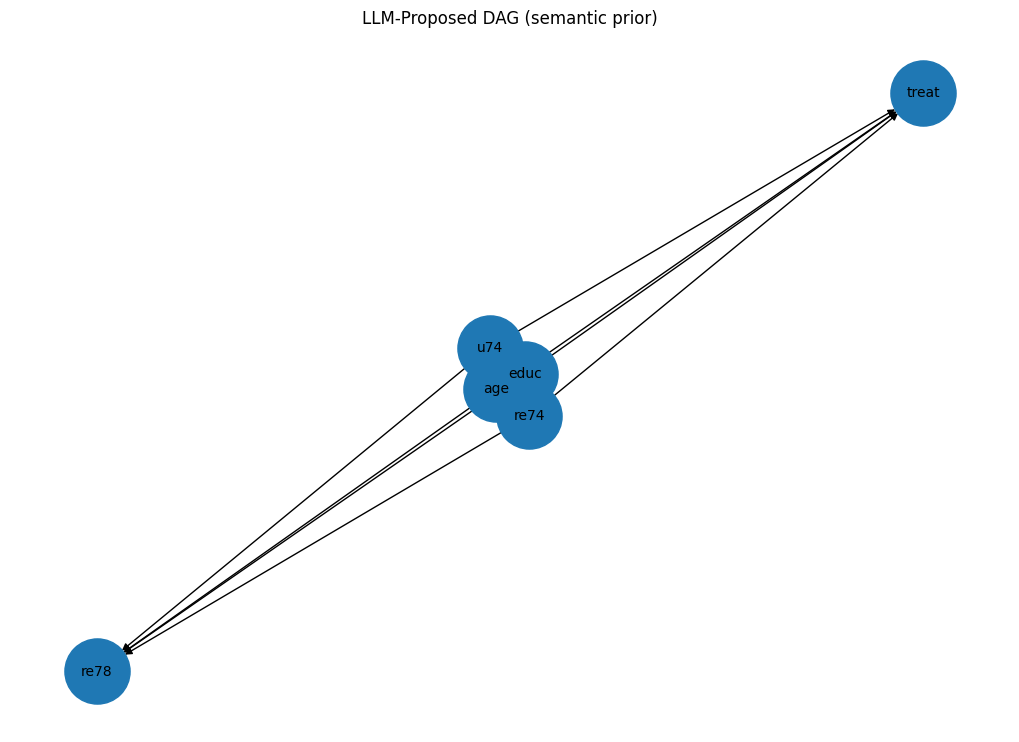

In [7]:
draw_edge_list_dag(edges, title="LLM-Proposed DAG (semantic prior)")


## 10. PC algorithm

Now we apply the **PC algorithm** (constraint-based causal discovery).

Key idea:
- LLM: semantic/domain prior
- PC: statistical conditional independence evidence

They often disagree — that disagreement is a *feature* for discussion (the final judgement by the expert is often needed!).


In [25]:
cg, numeric_df = run_pc(df, alpha=0.05)

print('Nodes:', numeric_df.columns.tolist())
print('PC graph object:')
print(cg.G)

# A lightweight edge listing (if available in this causal-learn version)
try:
    print('\nDiscovered edges:')
    for e in cg.G.get_graph_edges():
        print(' -', e)
except Exception as e:
    print('Could not list edges via get_graph_edges(); this is OK for the demo.')
    print('Error:', repr(e))


  0%|          | 0/12 [00:00<?, ?it/s]

Nodes: ['treat', 'age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75', 're78', 'u74', 'u75']
PC graph object:
Graph Nodes:
treat;age;educ;black;hisp;married;nodegr;re74;re75;re78;u74;u75

Graph Edges:
1. treat --- nodegr
2. treat --- re78
3. married --> age
4. nodegr --> age
5. hisp --> educ
6. nodegr --> educ
7. hisp --> black
8. re78 --> black
9. re75 --> married
10. re74 --> re75
11. re74 --- u74
12. u75 --> re75
13. u74 --- u75


Discovered edges:
 - treat --- nodegr
 - treat --- re78
 - married --> age
 - nodegr --> age
 - hisp --> educ
 - nodegr --> educ
 - hisp --> black
 - re78 --> black
 - re75 --> married
 - re74 --> re75
 - re74 --- u74
 - u75 --> re75
 - u74 --- u75


### Note: PC on mixed data (binary + continuous)

The Lalonde dataset mixes **binary** variables (including `treat`) with **continuous** earnings variables.
PC relies on conditional independence (CI) tests, and the default settings are often most appropriate for *continuous* variables.

Practical implication for this demo:
- edges involving `treat` may be **missing or ambiguous** even if confounding exists,
- directions may be unstable,
- use the PC output as a **hint** and combine it with domain/LLM reasoning.


In [24]:
directed_edges, undirected_edges = pc_graph_to_edge_lists(cg)
print("Directed edges (u -> v):", directed_edges)
print("Undirected / ambiguous edges (u -- v):", undirected_edges)

pc_edges_llm_format = [[u, v] for (u, v) in directed_edges]
print("\nDirected edges in LLM edge-list format:")
print(pc_edges_llm_format)


Directed edges (u -> v): [('married', 'age'), ('nodegr', 'age'), ('hisp', 'educ'), ('nodegr', 'educ'), ('hisp', 'black'), ('re78', 'black'), ('re75', 'married'), ('re74', 're75'), ('u75', 're75')]
Undirected / ambiguous edges (u -- v): [('nodegr', 'treat'), ('re74', 'u74'), ('re78', 'treat'), ('u74', 'u75')]

Directed edges in LLM edge-list format:
[['married', 'age'], ['nodegr', 'age'], ['hisp', 'educ'], ['nodegr', 'educ'], ['hisp', 'black'], ['re78', 'black'], ['re75', 'married'], ['re74', 're75'], ['u75', 're75']]


### Visualize PC output (directed and undirected edges)

PC can return a *partially oriented* graph. Here we draw:
- **directed edges** as solid arrows
- **undirected/ambiguous edges** as dashed gray lines


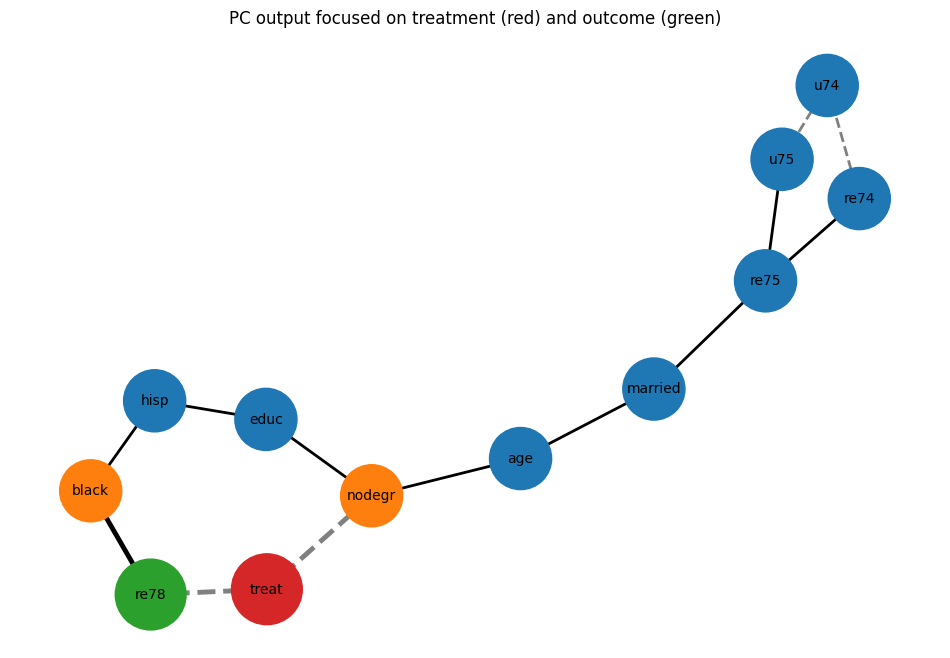

In [23]:
TREATMENT = 'treat'
OUTCOME = 're78'

draw_pc_graph(
    directed_edges,
    undirected_edges,
    treatment=TREATMENT,
    outcome=OUTCOME,
)


### How does PC help with the treatment question (`treat` → `re78`)?

For the causal question *“Does job training (`treat`) increase earnings in 1978 (`re78`)?”* the PC graph is useful in a **pragmatic** way:

- **Candidate confounders:** variables connected to both `treat` and `re78` are candidates for backdoor adjustment (often `re74`, `re75`, `educ`, …).
- **Mediators vs. confounders:** if PC suggests a variable is *downstream* of `treat`, adjusting for it could block part of the treatment effect.
- **Uncertainty matters:** undirected/ambiguous edges indicate PC cannot orient the relationship from conditional independences alone. Do not over-interpret directions.

In short: PC does not *solve* the causal question, but it can highlight which variables are statistically entangled with treatment and outcome and therefore deserve careful causal thinking.


### Example: using *LLM prior + PC hints* to build a DoWhy graph

A reliable DoWhy graph is not “whatever the LLM says” nor “whatever PC says”. A practical teaching workflow is:

1. **Start with domain/LLM hypotheses** about plausible causes of treatment selection and earnings.
2. **Check PC** for statistical dependencies and partial orientations around `treat` and `re78`.
3. **Choose a conservative adjustment set** of *pre-treatment* variables that plausibly affect both `treat` and `re78`.
4. Encode that as a DoWhy graph and estimate the effect.

Below is a small helper that proposes a *teaching* graph by combining:
- LLM-proposed edges (semantic prior)
- PC adjacency around `treat` and `re78` (statistical hint)

**Important:** This is not automatic causal discovery; it just illustrates how you can reconcile two information sources.


#### From “pre-domain-prune” candidates to a hand-picked adjustment set

The printed list **Suggested adjustment candidates (pre-domain-prune)** is a *union of hints* from two sources:

- **PC neighbors** of `treat` or `re78` (statistical dependence / adjacency), and
- **LLM candidates** that appear in an LLM edge touching `treat` or `re78` (semantic prior).

It is called *pre-domain-prune* because this list can still contain variables you **should not adjust for** (e.g., post-treatment mediators, colliders, or variables that violate temporal ordering).

To get a **hand-picked adjustment set**, we apply causal domain knowledge and keep a conservative subset of **pre-treatment covariates** that plausibly affect both treatment assignment and the outcome. In this teaching example we pick `educ`, `re74`, and `re75` because they are clearly pre-treatment and are plausible common causes of both training participation and later earnings.


**One-sentence rationale for the hand-picked adjustment set:**

- `educ`: Education is pre-treatment and influences both selection into training and future earnings potential.
- `re74`: Earnings in 1974 are pre-treatment and summarize baseline labor-market status that affects program participation and later earnings.
- `re75`: Earnings in 1975 are the most recent pre-treatment earnings and strongly predict `re78` while also influencing selection into training.

**How we form the final DoWhy graph from `adjust`:**

Given an adjustment set `adjust = {Z1, Z2, ...}`, we build a conservative *backdoor* graph by adding edges `Zi → treat` and `Zi → re78` for every `Zi ∈ adjust`, plus the causal edge `treat → re78`. This encodes the assumption that conditioning on `adjust` blocks all backdoor paths from `treat` to `re78` (i.e., no remaining unobserved confounding after adjustment).
**Note:** It is normal if a domain-chosen variable (e.g. `re75`) is missing from the pre-domain-prune list — that list is only a PC+LLM heuristic, not a definitive confounder set.


In [17]:
TREATMENT = 'treat'
OUTCOME = 're78'

# Build an adjacency graph from the PC output (ignore directions for neighborhood lookup).
G_all = nx.Graph()
G_all.add_edges_from(undirected_edges)
G_all.add_edges_from([(u, v) for (u, v) in directed_edges])

def neighbors_of(node: str) -> set[str]:
    return set(G_all.neighbors(node)) if node in G_all else set()

# 1) Candidates from PC: neighbors of treatment and outcome
pc_neighbor_candidates = sorted((neighbors_of(TREATMENT) | neighbors_of(OUTCOME)) - {TREATMENT, OUTCOME})
print('PC neighbors of treat/re78:', pc_neighbor_candidates)

# 2) Candidates from LLM: any node that appears in an edge touching treat or re78
llm_candidates = set()
for a, b in edges:
    if a in (TREATMENT, OUTCOME) or b in (TREATMENT, OUTCOME):
        llm_candidates.add(a)
        llm_candidates.add(b)
llm_candidates.discard(TREATMENT)
llm_candidates.discard(OUTCOME)
print('LLM candidates touching treat/re78:', sorted(llm_candidates))

# 3) Conservative adjustment set suggestion (then domain-prune)
suggested_adjust = sorted((set(pc_neighbor_candidates) | set(llm_candidates)) & set(df.columns))
print('Suggested adjustment candidates (pre-domain-prune):', suggested_adjust)

# For this teaching example, we pick a common pre-treatment subset by hand
adjust = [v for v in ['educ', 're74', 're75'] if v in df.columns]
print('Chosen adjustment set (teaching):', adjust)

# Note: the hand-picked set is a domain-driven override; it may include variables not surfaced by PC/LLM in this run
missing_from_pre = [v for v in adjust if v not in suggested_adjust]
if missing_from_pre:
    print('Note: hand-picked variables not in pre-domain-prune:', missing_from_pre)

graph_from_llm_pc = build_backdoor_dot_graph(adjust, treatment=TREATMENT, outcome=OUTCOME)
print('\nProposed DoWhy graph (teaching example):\n')
print(graph_from_llm_pc)


PC neighbors of treat/re78: ['black', 'nodegr']
LLM candidates touching treat/re78: ['age', 'educ', 're74', 'u74']
Suggested adjustment candidates (pre-domain-prune): ['age', 'black', 'educ', 'nodegr', 're74', 'u74']
Chosen adjustment set (teaching): ['educ', 're74', 're75']
Note: hand-picked variables not in pre-domain-prune: ['re75']

Proposed DoWhy graph (teaching example):

digraph {
  educ -> treat;
  educ -> re78;
  re74 -> treat;
  re74 -> re78;
  re75 -> treat;
  re75 -> re78;
  treat -> re78;
}


## 11. Create DoWhy graph

For causal effect estimation, we must choose a graph (assumptions!).

Below is a deliberately simple backdoor-adjustment graph often used in teaching: past earnings and education affect both training participation and future earnings.


In [19]:
graph = graph_from_llm_pc

'''
#digraph {
#    educ -> treat;
#    educ -> re78;

#    re74 -> treat;
#    re74 -> re78;

#    re75 -> treat;
#    re75 -> re78;

#    treat -> re78;
#}
#'''

print(graph)


digraph {
  educ -> treat;
  educ -> re78;
  re74 -> treat;
  re74 -> re78;
  re75 -> treat;
  re75 -> re78;
  treat -> re78;
}


## 12. Estimate causal effect

We estimate the causal effect of training participation (`treat`) on future earnings (`re78`).


In [20]:
model = CausalModel(
    data=df,
    treatment='treat',
    outcome='re78',
    graph=graph,
)

identified_estimand = model.identify_effect()
print(identified_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                            
────────(E[re78|re75,educ,re74])
d[treat]                        
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,re75,educ,re74,U) = P(re78|treat,re75,educ,re74)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
   d                            
────────(E[re78|re75,educ,re74])
d[treat]                        
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,re75,educ,re74,U) = P(re78|treat,re75,educ,re74)



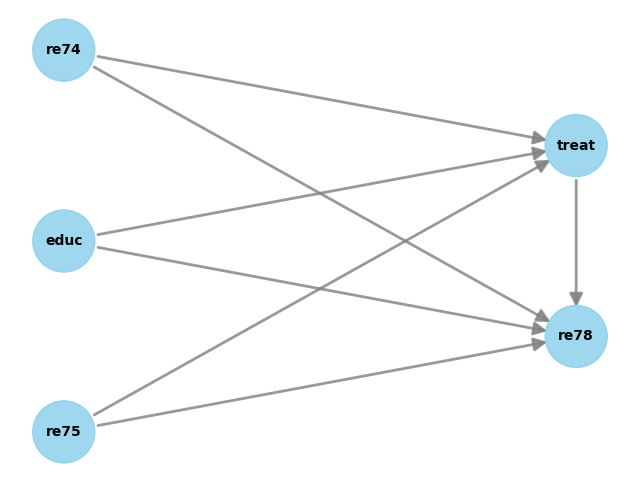

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                            
────────(E[re78|re75,educ,re74])
d[treat]                        
Estimand assumption 1, Unconfoundedness: If U→{treat} and U→re78 then P(re78|treat,re75,educ,re74,U) = P(re78|treat,re75,educ,re74)

## Realized estimand
b: re78~treat+re75+educ+re74
Target units: ate

## Estimate
Mean value: 1672.9840792193809

Estimated ATE (value): 1672.9840792193809


In [21]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name='backdoor.linear_regression',
)
model.view_model()
print(estimate)
print('Estimated ATE (value):', estimate.value)


### Interpreting the DoWhy estimate

The printed value above is an estimate of the **Average Treatment Effect (ATE)** of the job training program (`treat`) on 1978 earnings (`re78`).

- **Meaning:** the expected difference in `re78` if everyone were treated vs. if everyone were untreated, *under the causal graph assumptions and the chosen estimator*.
- **Units:** `re78` is earnings in 1978 (dollars), so the ATE is interpreted as “$ increase (or decrease) in 1978 earnings due to training”.
- **Key assumption:** the backdoor adjustment implied by the graph is valid (no unobserved confounding after conditioning on the chosen covariates).
- **Estimator assumption:** linear regression is a simple model; misspecification can bias estimates.

Next we run a few **refutation tests** to sanity-check robustness. These refuters do *not* prove causality, but they can catch obvious fragility.


In [22]:
# Refutation tests (sanity checks)
import numpy as np

np.random.seed(42)

print("Original estimate:", estimate.value)

ref_random = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
)
print("\n[Refuter] random_common_cause")
print(ref_random)

ref_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
)
print("\n[Refuter] placebo_treatment_refuter (permute)")
print(ref_placebo)

ref_subset = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=10,
)
print("\n[Refuter] data_subset_refuter")
print(ref_subset)


Original estimate: 1672.9840792193809

[Refuter] random_common_cause
Refute: Add a random common cause
Estimated effect:1672.9840792193809
New effect:1674.6868730031972
p value:0.96


[Refuter] placebo_treatment_refuter (permute)
Refute: Use a Placebo Treatment
Estimated effect:1672.9840792193809
New effect:-82.85327046090553
p value:0.96


[Refuter] data_subset_refuter
Refute: Use a subset of data
Estimated effect:1672.9840792193809
New effect:1687.683999888482
p value:0.46915755822241273



## 13. Discussion

### Refutation tests (sanity checks)
We ran three refuters and printed their outputs above. Here are the **actual results from this run** (from the executed notebook output):

(Below values are from one representative run and sightly can change, but the overall reasoning should remain)
- **Estimated ATE:** `1672.9841`
- **random_common_cause:** New effect `1674.6869` (Δ `+1.7028`), p-value `0.96`
- **placebo_treatment_refuter (permute):** New effect `-82.8533` (close to 0), p-value `0.96`
- **data_subset_refuter:** New effect `1687.6840` (Δ `+14.6999`), p-value `0.4692`

Interpretation notes:
- The **random common cause** refuter barely changes the estimate (≈ +$1.70), which is consistent with a relatively stable estimate under this particular stress-test.
- The **placebo** refuter produces a near-zero estimate (≈ -$82.85) — that’s what we want to see if the pipeline is not spuriously finding an effect when the treatment is randomized.
- The **subset** refuter yields a similar magnitude to the original estimate (≈ +$14.70 difference here), suggesting the estimate is not very unstable under subsampling (though you may see variation across runs).

When these refuters behave as expected (placebo near 0; random confounder does not drastically change the estimate; subset refuter yields similar magnitude), it increases confidence that the estimate is not purely an artifact — **but it still does not prove the causal graph is correct, it only give further indications**.


Key lessons:

- LLMs can quickly propose a *candidate* causal structure (semantic prior).
- Statistical discovery (PC) provides *evidence-based* structure hints.
- DoWhy shows how graph assumptions determine identification and estimation.
- Human expertise remains essential: you must decide which variables to adjust for, and whether the causal assumptions are defensible.

### What the DoWhy result means
- The ATE printed above is our estimate of the average causal effect of training on 1978 earnings, under the chosen graph and linear-regression backdoor estimator.
- If the adjustment set is incomplete (unobserved confounding), the estimate can be biased even if it is statistically precise.

Modern causal workflows increasingly combine:
- domain expertise,
- LLM assistance,
- statistical discovery,
- and causal inference frameworks.